# Pipeline: WavLM + MASR + PhoWhisper-Large

**Pipeline (Diarization-First):**
```
                    ┌──────────────────────────────────┐
                    │         Upload Audio File         │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │     VAD (Voice Activity Detect)   │
                    │   Phát hiện đoạn có người nói     │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │        Cut & Merge Segments       │
                    │  Gộp đoạn ngắn, cắt đoạn dài     │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │   Load Models (WavLM + MASR +     │
                    │   PhoWhisper-Large)               │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │   WavLM Sliding Window (1.5s)     │
                    │   Speaker Embedding Extraction    │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │     Spectral Clustering           │
                    │   StandardScaler + NN Affinity    │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │     Speaker Segments              │
                    │  Xác định: Ai nói từ lúc nào?     │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │  MASR Verification (per segment) │
                    │                                  │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │   PhoWhisper-Large ASR            │
                    │  Chạy ASR trên TỪNG speaker seg   │
                    └──────────────┬───────────────────┘
                                   ↓
                    ┌──────────────────────────────────┐
                    │        Merge & Export             │
                    │    TXT / SRT / JSON output        │
                    └──────────────────────────────────┘
```

**Models:**
| Model | Vai trò | Source |
|---|---|---|
| **WavLM-base-plus-sv** | Speaker Embedding (512-dim) | `microsoft/wavlm-base-plus-sv` |
| **MASR (ViMD,AMI)** | Diarization   | Checkpoint (đã train) |
| **PhoWhisper-Large** | ASR tiếng Việt | `vinai/PhoWhisper-large` |


In [17]:
# Cell 1: Setup
# Chạy cell này kết nối colab rồi upload file audio test ở /content/test_audio ở menu file dọc bên trái
!pip install -q transformers accelerate soundfile librosa jiwer

import os, sys, json, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import librosa
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

if os.path.exists('/content'):
    from google.colab import drive
    drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
os.makedirs('/content/test_audio', exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [18]:
# Cell 2: Config
class Config:
    # Models
    DIAR_MODEL_BASE = 'vinai/PhoWhisper-small'
    DIAR_CHECKPOINT = '/content/drive/MyDrive/Method/best_model.pt'  # <-- SUA DUONG DAN DEN FILE MODEL NEU BAO LOI KHONG TIM THAY
    ASR_MODEL_NAME = 'vinai/PhoWhisper-large'
    MAX_SPEAKERS = 2 # chinh theo so luong nguoi thuc te
    NUM_SPEAKERS_EXPECTED = 2   # So nguoi noi expected

    # Audio
    SAMPLE_RATE = 16000
    HOP_LENGTH = 320

    # VAD
    VAD_ENERGY_THRESHOLD = 0.008
    VAD_MIN_SPEECH_SEC = 0.3
    VAD_MIN_SILENCE_SEC = 0.3

    # Diarization (WavLM Sliding Window)
    DIAR_WINDOW_SEC = 1.5     # Window size for WavLM
    DIAR_STEP_SEC = 0.5       # Step size (overlap)
    DIAR_BATCH_SIZE = 16      # Batch WavLM calls
    DIAR_SMOOTH_KERNEL = 5    # Median filter kernel
    DIAR_MIN_SEGMENT_SEC = 1.0  # Minimum speaker segment duration

    # Cross-Reference
    MASR_WEIGHT = 0.15
    WAVLM_WEIGHT = 0.85

    # Merge
    MERGE_GAP_SEC = 1.0       # Merge segments gap < 1s

    OUTPUT_DIR = '/content/drive/MyDrive/Method/results_pipeline'

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print("Config ready!")


Config ready!


---
## 1. Upload Audio File

Upload file audio từ máy tính (WAV, MP3, M4A, FLAC, OGG, WEBM).


In [19]:
# Cell 3: Upload Audio
from google.colab import files

print("Chon file audio tu may tinh...")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    AUDIO_PATH = f'/content/test_audio/{filename}'

    # Save to disk
    with open(AUDIO_PATH, 'wb') as f:
        f.write(uploaded[filename])

    print(f"\n\u2713 Uploaded: {filename} ({len(uploaded[filename])/1024/1024:.1f} MB)")
else:
    # Fallback: tim file co san
    audio_files = glob.glob('/content/test_audio/*.*')
    audio_exts = [f for f in audio_files if f.endswith(('.wav','.mp3','.m4a','.webm','.ogg','.flac'))]
    if audio_exts:
        AUDIO_PATH = audio_exts[0]
        print(f"Found existing: {AUDIO_PATH}")
    else:
        raise FileNotFoundError("Upload audio hoac copy vao /content/test_audio/")

# Load audio
audio, sr = librosa.load(AUDIO_PATH, sr=cfg.SAMPLE_RATE, mono=True)
duration = len(audio) / sr
print(f"\u2713 Audio: {duration:.1f}s ({duration/60:.1f} min)")


Chon file audio tu may tinh...


Saving khi-gim-c-i-xin-vic-oppo-find-n5-x-gio-s-xoay-x-an-tr_zCZLpSFr.mp3 to khi-gim-c-i-xin-vic-oppo-find-n5-x-gio-s-xoay-x-an-tr_zCZLpSFr (1).mp3

✓ Uploaded: khi-gim-c-i-xin-vic-oppo-find-n5-x-gio-s-xoay-x-an-tr_zCZLpSFr (1).mp3 (2.3 MB)
✓ Audio: 60.5s (1.0 min)


---
## 2. Voice Activity Detection (VAD)

Phát hiện các đoạn có người nói, bỏ qua khoảng im lặng.

```
Input Audio ──→ [Energy VAD] ──→ Speech Segments
                                   ┌───┐ ┌──┐ ┌────────┐ ┌───┐
                                   │ 1 │ │2 │ │   3    │ │ 4 │
                                   └───┘ └──┘ └────────┘ └───┘
```


In [20]:
# Cell 4: Voice Activity Detection
def energy_vad(audio, sr, threshold=0.01, min_speech=0.3, min_silence=0.3):
    frame_len = int(sr * 0.03)
    hop = frame_len // 2
    n_frames = max(1, (len(audio) - frame_len) // hop + 1)

    energy = np.array([
        np.sum(audio[i*hop:i*hop+frame_len]**2) / frame_len
        for i in range(n_frames)
    ])
    if energy.max() > 0:
        energy /= energy.max()

    is_speech = energy > threshold

    # Fill short silence gaps
    min_sil_f = int(min_silence * 1000 / 30)
    i = 0
    while i < len(is_speech):
        if not is_speech[i]:
            j = i
            while j < len(is_speech) and not is_speech[j]: j += 1
            if j - i < min_sil_f and i > 0 and j < len(is_speech):
                is_speech[i:j] = True
            i = j
        else:
            i += 1

    segs = []
    in_s = False; start = 0
    for i in range(len(is_speech)):
        if is_speech[i] and not in_s: start = i; in_s = True
        elif not is_speech[i] and in_s:
            s_sec = max(0, start * hop / sr - 0.15)
            e_sec = min(len(audio)/sr, i * hop / sr + 0.15)
            if e_sec - s_sec >= min_speech:
                segs.append((s_sec, e_sec))
            in_s = False
    if in_s:
        s_sec = max(0, start * hop / sr - 0.15)
        e_sec = len(audio) / sr
        if e_sec - s_sec >= min_speech:
            segs.append((s_sec, e_sec))

    return segs if segs else [(0, len(audio)/sr)]

vad_segments = energy_vad(
    audio, sr,
    threshold=cfg.VAD_ENERGY_THRESHOLD,
    min_speech=cfg.VAD_MIN_SPEECH_SEC,
    min_silence=cfg.VAD_MIN_SILENCE_SEC
)

total_speech = sum(e-s for s, e in vad_segments)
print(f"\u2713 VAD: {len(vad_segments)} speech segments")
print(f"  Speech: {total_speech:.1f}s / {duration:.1f}s ({total_speech/duration*100:.0f}%)")


✓ VAD: 29 speech segments
  Speech: 46.0s / 60.5s (76%)


---
## 3. Cut & Merge

- **Merge**: Gộp segments ngắn (<3s) với segment liền kề
- **Cut**: Cắt segments dài (>30s) thành phần nhỏ hơn

```
VAD:     [──seg1──] [s2] [────seg3────────────] [s4]
                           ↓ Cut & Merge
Chunks:  [──chunk1──────] [──chunk2──] [──chunk3──] [chunk4]
```


In [21]:
# Cell 5: Cut & Merge
def cut_and_merge(vad_segments, min_chunk=1.0, max_chunk=30.0, merge_short=3.0):
    if not vad_segments:
        return []

    merged_segs = [list(vad_segments[0])]
    for seg_start, seg_end in vad_segments[1:]:
        prev_start, prev_end = merged_segs[-1]
        seg_dur = seg_end - seg_start
        gap = seg_start - prev_end

        if seg_dur < merge_short or (gap < 1.0 and prev_end - prev_start + seg_dur + gap <= max_chunk):
            merged_segs[-1][1] = seg_end
        else:
            merged_segs.append([seg_start, seg_end])

    chunks = []
    for seg_start, seg_end in merged_segs:
        seg_dur = seg_end - seg_start
        if seg_dur <= max_chunk:
            if seg_dur >= min_chunk:
                chunks.append((seg_start, seg_end))
        else:
            pos = seg_start
            while pos < seg_end:
                chunk_end = min(pos + max_chunk, seg_end)
                if chunk_end - pos >= min_chunk:
                    chunks.append((pos, chunk_end))
                pos += max_chunk - 2.0

    return chunks

chunks = cut_and_merge(vad_segments, min_chunk=1.0, max_chunk=30.0, merge_short=3.0)
chunk_durs = [e-s for s, e in chunks]
print(f"\u2713 Cut & Merge: {len(vad_segments)} VAD -> {len(chunks)} chunks")
print(f"  Duration: min={min(chunk_durs):.1f}s, max={max(chunk_durs):.1f}s, mean={np.mean(chunk_durs):.1f}s")


✓ Cut & Merge: 29 VAD -> 3 chunks
  Duration: min=3.9s, max=30.0s, mean=19.8s


---
## 4. Load Models

| Model | Kích thước | Vai trò |
|---|---|---|
| **WavLM-base-plus-sv** | ~94M params | Speaker Embedding (512-dim) |
| **MASR (PhoWhisper-small)** | ~244M params | Diarization |
| **PhoWhisper-Large** | ~1.5B params | ASR tiếng Việt (FP16) |


In [22]:
# Cell 6: Model Definitions
class TSROPE(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model
        self.div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
    def forward(self, x, speaker_shift=0):
        seq_len = x.size(1)
        t = torch.arange(seq_len, device=x.device).float().unsqueeze(1)
        t_shifted = t + speaker_shift
        angles = t_shifted * self.div_term
        sin = torch.sin(angles)
        cos = torch.cos(angles)
        x_left = x[..., 0::2]
        x_right = x[..., 1::2]
        x_rotated = torch.zeros_like(x)
        x_rotated[..., 0::2] = x_left * cos - x_right * sin
        x_rotated[..., 1::2] = x_left * sin + x_right * cos
        return x_rotated
class TSPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:x.size(1)]

class HyperSDModule(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_speakers=4, num_classes=5):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.GELU(), nn.Dropout(0.1)
        )
        self.speaker_head = nn.Linear(hidden_dim, num_speakers)
        self.class_head = nn.Linear(hidden_dim, num_classes)
    def forward(self, h):
        h = self.proj(h)
        return self.speaker_head(h), self.class_head(h)

class MASR(nn.Module):
    def __init__(self, phowhisper, hidden_dim=256, num_speakers=4):
        super().__init__()
        self.phowhisper = phowhisper
        self.encoder_dim = phowhisper.config.d_model
        self.ts_pos = TSPositionalEncoding(self.encoder_dim)
        self.hyper_sd = HyperSDModule(self.encoder_dim, hidden_dim, num_speakers)

    def forward_diarization(self, feats):
        with torch.no_grad():
            enc = self.phowhisper.model.encoder(feats)
            h = self.ts_pos(enc.last_hidden_state)
            spk_logits, cls_logits = self.hyper_sd(h)
            return torch.sigmoid(spk_logits), cls_logits

print("Model definitions ready")


Model definitions ready


In [23]:
# Cell 7: Load Models
# 1. MASR
print("Loading MASR...")
proc_diar = WhisperProcessor.from_pretrained(cfg.DIAR_MODEL_BASE)
model_base = WhisperForConditionalGeneration.from_pretrained(cfg.DIAR_MODEL_BASE)

# --- FIX: Match Checkpoint Configuration ---
# The checkpoint was likely trained with 4 speakers, so we must init with 4.
CHECKPOINT_NUM_SPEAKERS = 4

# Add special tokens.
# Note: If there's still a mismatch, we might need to pad the vocab to 50368 exactly.
special_tokens = [f'<|spk{i}|>' for i in range(1, CHECKPOINT_NUM_SPEAKERS+1)]
proc_diar.tokenizer.add_tokens(special_tokens)
model_base.resize_token_embeddings(len(proc_diar.tokenizer))

# Force resize if it doesn't match 50368 (commonly divisible by 64 or specific to the training run)
# The error says checkpoint has 50368.
if model_base.config.vocab_size != 50368 and len(proc_diar.tokenizer) != 50368:
    # Sometimes explicit resize is needed if standard add_tokens doesn't hit the target number
    # or if the checkpoint used a specific padded size.
    print(f"Adjusting vocab size to match checkpoint: 50368 (current: {len(proc_diar.tokenizer)})")
    model_base.resize_token_embeddings(50368)

masr = MASR(model_base, 256, CHECKPOINT_NUM_SPEAKERS).to(device)

masr_available = False
if os.path.exists(cfg.DIAR_CHECKPOINT):
    try:
        ckpt = torch.load(cfg.DIAR_CHECKPOINT, map_location=device, weights_only=False)
        sd = ckpt.get('model', ckpt.get('model_state_dict', ckpt))
        masr.load_state_dict(sd, strict=False)
        print("  ✓ MASR loaded!")
        masr_available = True
    except Exception as e:
        print(f"  ⚠ Error loading MASR checkpoint: {e}")
        print("    Pipeline se van chay (chi dung WavLM)")
else:
    print(f"  ⚠ Checkpoint not found: {cfg.DIAR_CHECKPOINT}")
    print("    Pipeline se van chay (chi dung WavLM)")
masr.eval()

# 2. WavLM Speaker Encoder
print("Loading WavLM Speaker Encoder...")
from transformers import Wav2Vec2FeatureExtractor, WavLMForXVector
wavlm_feat = Wav2Vec2FeatureExtractor.from_pretrained('microsoft/wavlm-base-plus-sv')
wavlm_model = WavLMForXVector.from_pretrained('microsoft/wavlm-base-plus-sv').to(device)
wavlm_model.eval()
print("  ✓ WavLM loaded! (512-dim speaker embeddings)")

# 3. PhoWhisper-Large (ASR)
print(f"Loading {cfg.ASR_MODEL_NAME} (FP16)...")
proc_asr = WhisperProcessor.from_pretrained(cfg.ASR_MODEL_NAME)
model_asr = WhisperForConditionalGeneration.from_pretrained(
    cfg.ASR_MODEL_NAME, torch_dtype=torch.float16
).to(device)
model_asr.eval()
print("  ✓ PhoWhisper-Large loaded!")

print(f"\n✓ All 3 models ready!")

Loading MASR...


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 720, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/vinai/PhoWhisper-small/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.p

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to proj_out.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  ✓ MASR loaded!
Loading WavLM Speaker Encoder...


...

  ✓ WavLM loaded! (512-dim speaker embeddings)
Loading vinai/PhoWhisper-large (FP16)...


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 720, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/vinai/PhoWhisper-large/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.p

Loading weights:   0%|          | 0/1260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to proj_out.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  ✓ PhoWhisper-Large loaded!

✓ All 3 models ready!


---
## 5. WavLM Diarization (Sliding Window)

**Bước quan trọng nhất:** Quét toàn bộ audio bằng cửa sổ trượt 1.5s, trích xuất WavLM embeddings, rồi clustering để xác định **ai nói khi nào**.

```
Audio: ════════════════════════════════════════════
       ├──1.5s──┤                                   Window 1 → Embedding 1
          ├──1.5s──┤                                Window 2 → Embedding 2
             ├──1.5s──┤                             Window 3 → Embedding 3
                ...
                                                         ↓
                                              StandardScaler + L2 Norm
                                                         ↓
                                              Spectral Clustering (k=2)
                                                         ↓
                                              Median Filter (smooth)
                                                         ↓
                                         Speaker Segments (Ai nói lúc nào?)
```


In [24]:
'''
# Cell 8: WavLM Diarization (Sliding Window)
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import SpectralClustering
from scipy.signal import medfilt

DIAR_WINDOW = cfg.DIAR_WINDOW_SEC
DIAR_STEP = cfg.DIAR_STEP_SEC

# 1. Extract all windows
total_dur = len(audio) / sr
windows_audio = []
window_times = []

pos = 0.0
while pos + DIAR_WINDOW <= total_dur + 0.3:
    win_end = min(pos + DIAR_WINDOW, total_dur)
    win = audio[int(pos*sr):int(win_end*sr)]
    if len(win) >= int(0.5 * sr):
        windows_audio.append(win)
        window_times.append((pos, win_end))
    pos += DIAR_STEP

print(f"Windows: {len(windows_audio)} ({DIAR_WINDOW}s window, {DIAR_STEP}s step)")

# 2. Batch WavLM embeddings
all_embs = []
for i in tqdm(range(0, len(windows_audio), cfg.DIAR_BATCH_SIZE), desc="WavLM Embeddings"):
    batch = windows_audio[i:i+cfg.DIAR_BATCH_SIZE]
    inputs = wavlm_feat(batch, sampling_rate=sr, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = wavlm_model(**inputs)
        embs = out.embeddings.cpu().numpy()
    all_embs.append(embs)

all_embs = np.concatenate(all_embs, axis=0)
print(f"Embeddings: {all_embs.shape}")

# 3. StandardScaler + L2 Normalize
scaler = StandardScaler()
embs_scaled = scaler.fit_transform(all_embs)
embs_final = normalize(embs_scaled, norm='l2')

# 4. Spectral Clustering
print(f"Spectral Clustering into {cfg.NUM_SPEAKERS_EXPECTED} speakers...")
clustering = SpectralClustering(
    n_clusters=cfg.NUM_SPEAKERS_EXPECTED,
    affinity='nearest_neighbors',
    n_neighbors=min(15, len(embs_final)-1),
    assign_labels='discretize',
    random_state=42
)
window_labels = clustering.fit_predict(embs_final)

# 5. Median filter smoothing
window_labels_smooth = medfilt(window_labels, kernel_size=cfg.DIAR_SMOOTH_KERNEL).astype(int)
print(f"Cluster distribution: {Counter(window_labels_smooth + 1)}")

# 6. Convert to speaker segments
speaker_segments = []
current_spk = window_labels_smooth[0]
current_start = window_times[0][0]

for i in range(1, len(window_labels_smooth)):
    if window_labels_smooth[i] != current_spk:
        mid = (window_times[i-1][1] + window_times[i][0]) / 2
        speaker_segments.append({
            'start': current_start,
            'end': mid,
            'wavlm_speaker': int(current_spk) + 1
        })
        current_spk = window_labels_smooth[i]
        current_start = mid

speaker_segments.append({
    'start': current_start,
    'end': window_times[-1][1],
    'wavlm_speaker': int(current_spk) + 1
})

# 7. Merge short segments (<1s) with neighbors
merged_segs = [speaker_segments[0].copy()]
for seg in speaker_segments[1:]:
    prev = merged_segs[-1]
    if seg['end'] - seg['start'] < cfg.DIAR_MIN_SEGMENT_SEC:
        prev['end'] = seg['end']
    elif seg['wavlm_speaker'] == prev['wavlm_speaker']: # Corrected from prev['speaker']
        prev['end'] = seg['end']
    else:
        merged_segs.append(seg.copy())

speaker_segments = merged_segs
print(f"\n\u2713 Speaker segments: {len(speaker_segments)}")

for seg in speaker_segments[:15]:
    ms, ss = int(seg['start']//60), int(seg['start']%60)
    me, se = int(seg['end']//60), int(seg['end']%60)
    dur = seg['end'] - seg['start']
    print(f"  [{ms:02d}:{ss:02d}-{me:02d}:{se:02d}] ({dur:.1f}s) Speaker {seg['wavlm_speaker']}")
if len(speaker_segments) > 15:
    print(f"  ... + {len(speaker_segments)-15} more")

torch.cuda.empty_cache()
'''


'\n# Cell 8: WavLM Diarization (Sliding Window)\nfrom sklearn.preprocessing import StandardScaler, normalize\nfrom sklearn.cluster import SpectralClustering\nfrom scipy.signal import medfilt\n\nDIAR_WINDOW = cfg.DIAR_WINDOW_SEC\nDIAR_STEP = cfg.DIAR_STEP_SEC\n\n# 1. Extract all windows\ntotal_dur = len(audio) / sr\nwindows_audio = []\nwindow_times = []\n\npos = 0.0\nwhile pos + DIAR_WINDOW <= total_dur + 0.3:\n    win_end = min(pos + DIAR_WINDOW, total_dur)\n    win = audio[int(pos*sr):int(win_end*sr)]\n    if len(win) >= int(0.5 * sr):\n        windows_audio.append(win)\n        window_times.append((pos, win_end))\n    pos += DIAR_STEP\n\nprint(f"Windows: {len(windows_audio)} ({DIAR_WINDOW}s window, {DIAR_STEP}s step)")\n\n# 2. Batch WavLM embeddings\nall_embs = []\nfor i in tqdm(range(0, len(windows_audio), cfg.DIAR_BATCH_SIZE), desc="WavLM Embeddings"):\n    batch = windows_audio[i:i+cfg.DIAR_BATCH_SIZE]\n    inputs = wavlm_feat(batch, sampling_rate=sr, return_tensors="pt", padding=

In [25]:
# Cell 8: WavLM Diarization (Sliding Window)
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import SpectralClustering
from scipy.signal import medfilt

DIAR_WINDOW = cfg.DIAR_WINDOW_SEC
DIAR_STEP = cfg.DIAR_STEP_SEC

windows_audio = []
window_times = []

for chunk_start, chunk_end in chunks:
    chunk_dur = chunk_end - chunk_start
    pos = 0.0
    while pos + DIAR_WINDOW <= chunk_dur + 0.3:
        abs_start = chunk_start + pos
        abs_end = min(chunk_start + pos + DIAR_WINDOW, chunk_end)
        win = audio[int(abs_start * sr):int(abs_end * sr)]
        if len(win) >= int(0.5 * sr):
            windows_audio.append(win)
            window_times.append((abs_start, abs_end))
        pos += DIAR_STEP
    # If chunk is shorter than DIAR_WINDOW, use entire chunk as one window
    if chunk_dur < DIAR_WINDOW and chunk_dur >= 0.5:
        win = audio[int(chunk_start * sr):int(chunk_end * sr)]
        if len(win) >= int(0.5 * sr) and (chunk_start, chunk_end) not in window_times:
            windows_audio.append(win)
            window_times.append((chunk_start, chunk_end))

print(f"\u2713 Windows: {len(windows_audio)} (from {len(chunks)} VAD chunks)")
print(f"  Window: {DIAR_WINDOW}s, Step: {DIAR_STEP}s")


# 2. Batch WavLM embeddings
all_embs = []
for i in tqdm(range(0, len(windows_audio), cfg.DIAR_BATCH_SIZE), desc="WavLM Embeddings"):
    batch = windows_audio[i:i+cfg.DIAR_BATCH_SIZE]
    inputs = wavlm_feat(batch, sampling_rate=sr, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = wavlm_model(**inputs)
        embs = out.embeddings.cpu().numpy()
    all_embs.append(embs)

all_embs = np.concatenate(all_embs, axis=0)
print(f"Embeddings: {all_embs.shape}")

# 3. StandardScaler + L2 Normalize
scaler = StandardScaler()
embs_scaled = scaler.fit_transform(all_embs)
embs_final = normalize(embs_scaled, norm='l2')

# 4. Spectral Clustering
print(f"Spectral Clustering into {cfg.NUM_SPEAKERS_EXPECTED} speakers...")
clustering = SpectralClustering(
    n_clusters=cfg.NUM_SPEAKERS_EXPECTED,
    affinity='nearest_neighbors',
    n_neighbors=min(15, len(embs_final)-1),
    assign_labels='discretize',
    random_state=42
)
window_labels = clustering.fit_predict(embs_final)

# 5. Median filter smoothing
window_labels_smooth = medfilt(window_labels, kernel_size=cfg.DIAR_SMOOTH_KERNEL).astype(int)
print(f"Cluster distribution: {Counter(window_labels_smooth + 1)}")

# 6. Convert to speaker segments
speaker_segments = []
current_spk = window_labels_smooth[0]
current_start = window_times[0][0]

for i in range(1, len(window_labels_smooth)):
    if window_labels_smooth[i] != current_spk:
        mid = (window_times[i-1][1] + window_times[i][0]) / 2
        speaker_segments.append({
            'start': current_start,
            'end': mid,
            'wavlm_speaker': int(current_spk) + 1
        })
        current_spk = window_labels_smooth[i]
        current_start = mid

speaker_segments.append({
    'start': current_start,
    'end': window_times[-1][1],
    'wavlm_speaker': int(current_spk) + 1
})

# 7. Merge short segments (<1s) with neighbors
merged_segs = [speaker_segments[0].copy()]
for seg in speaker_segments[1:]:
    prev = merged_segs[-1]
    if seg['end'] - seg['start'] < cfg.DIAR_MIN_SEGMENT_SEC:
        prev['end'] = seg['end']
    elif seg['wavlm_speaker'] == prev['wavlm_speaker']: # Corrected from prev['speaker']
        prev['end'] = seg['end']
    else:
        merged_segs.append(seg.copy())

speaker_segments = merged_segs
print(f"\n\u2713 Speaker segments: {len(speaker_segments)}")

for seg in speaker_segments[:15]:
    ms, ss = int(seg['start']//60), int(seg['start']%60)
    me, se = int(seg['end']//60), int(seg['end']%60)
    dur = seg['end'] - seg['start']
    print(f"  [{ms:02d}:{ss:02d}-{me:02d}:{se:02d}] ({dur:.1f}s) Speaker {seg['wavlm_speaker']}")
if len(speaker_segments) > 15:
    print(f"  ... + {len(speaker_segments)-15} more")

torch.cuda.empty_cache()


✓ Windows: 113 (from 3 VAD chunks)
  Window: 1.5s, Step: 0.5s


WavLM Embeddings:   0%|          | 0/8 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
WavLM Embeddings: 100%|██████████| 8/8 [00:01<00:00,  6.08it/s]


Embeddings: (113, 512)
Spectral Clustering into 2 speakers...
Cluster distribution: Counter({np.int64(1): 64, np.int64(2): 49})

✓ Speaker segments: 12
  [00:00-00:04] (4.5s) Speaker 1
  [00:04-00:07] (2.5s) Speaker 2
  [00:07-00:16] (9.0s) Speaker 1
  [00:16-00:19] (3.5s) Speaker 2
  [00:19-00:27] (8.0s) Speaker 1
  [00:27-00:30] (3.0s) Speaker 2
  [00:30-00:41] (10.5s) Speaker 1
  [00:41-00:46] (5.0s) Speaker 2
  [00:46-00:47] (1.5s) Speaker 1
  [00:47-00:52] (4.5s) Speaker 2
  [00:52-00:54] (2.5s) Speaker 1
  [00:54-01:00] (6.0s) Speaker 2


## 5. MASR Verification + Weighted Cross-Reference

In [26]:
# Cell 8b: MASR Verification + Weighted Cross-Reference
if masr_available:
    print("Running MASR verification on each segment...")
    for seg in tqdm(speaker_segments, desc="MASR Verification"):
        seg_audio = audio[int(seg['start']*sr):int(seg['end']*sr)]

        if len(seg_audio) < int(0.3 * sr):
            seg['masr_speaker'] = seg['wavlm_speaker']
            seg['masr_confidence'] = 0.0
            continue

        # MASR expects mel features
        feat = proc_diar.feature_extractor(
            seg_audio, sampling_rate=sr, return_tensors="pt"
        ).input_features.to(device)

        with torch.no_grad():
            spk_probs, _ = masr.forward_diarization(feat)

        probs = spk_probs.squeeze().cpu().numpy()
        # Average across frames
        mean_probs = probs.mean(axis=0)
        seg['masr_speaker'] = int(mean_probs.argmax()) + 1
        seg['masr_confidence'] = float(mean_probs.max())

    print("✓ MASR verification done!")
else:
    print("⚠ MASR not available, using WavLM only")
    for seg in speaker_segments:
        seg['masr_speaker'] = seg['wavlm_speaker']
        seg['masr_confidence'] = 0.0

# Weighted Cross-Reference
MASR_W = cfg.MASR_WEIGHT
WAVLM_W = cfg.WAVLM_WEIGHT

for seg in speaker_segments:
    wavlm_spk = seg['wavlm_speaker']
    masr_spk = seg['masr_speaker']
    masr_conf = seg['masr_confidence']

    scores = {}
    scores[wavlm_spk] = scores.get(wavlm_spk, 0) + WAVLM_W

    if 1 <= masr_spk <= cfg.NUM_SPEAKERS_EXPECTED:
        effective_w = MASR_W * masr_conf
        scores[masr_spk] = scores.get(masr_spk, 0) + effective_w

    # Final speaker = speaker co score cao nhat
    seg['final_speaker'] = max(scores, key=scores.get)
    seg['final_score'] = scores[seg['final_speaker']]

    # Source tracking
    if seg['final_speaker'] == wavlm_spk and seg['final_speaker'] == masr_spk:
        seg['source'] = 'BOTH'
    elif seg['final_speaker'] == wavlm_spk:
        seg['source'] = 'WavLM'
    else:
        seg['source'] = 'MASR'

'''# Summary
sources = Counter(seg['source'] for seg in speaker_segments)
print(f"\nCross-Reference Sources: {dict(sources)}")
print(f"{'#':>3} {'Time':>12} {'WavLM':>6} {'MASR':>6} {'MASR%':>6} {'Final':>6} {'Src':>6}")
print("-" * 60)
for i, seg in enumerate(speaker_segments[:15]):
    ms, ss = int(seg['start']//60), int(seg['start']%60)
    me, se = int(seg['end']//60), int(seg['end']%60)
    print(f"{i:>3} [{ms:02d}:{ss:02d}-{me:02d}:{se:02d}] Spk{seg['wavlm_speaker']:>2} Spk{seg['masr_speaker']:>2} "
          f"{seg['masr_confidence']:.1%} Spk{seg['final_speaker']:>2} {seg['source']:>6}")
if len(speaker_segments) > 15:
    print(f"  ... + {len(speaker_segments)-15} more")
'''
torch.cuda.empty_cache()


Running MASR verification on each segment...


MASR Verification: 100%|██████████| 12/12 [00:01<00:00,  7.90it/s]

✓ MASR verification done!


---
## 6. ASR per Speaker Segment

Chạy PhoWhisper-Large trên **từng speaker segment riêng biệt**.

```
Speaker Segments:
  [Spk1: 0-5s] [Spk2: 5-8s] [Spk1: 8-15s] [Spk2: 15-20s]
       ↓              ↓           ↓              ↓
   Whisper(1)    Whisper(2)  Whisper(3)    Whisper(4)
       ↓              ↓           ↓              ↓
   "xin chào"   "em chào"   "hôm nay..."  "dạ vâng..."
```

> **Tại sao không ASR trước?** Vì Whisper sẽ gộp giọng 2 người thành 1 câu. Phải tách speaker trước rồi mới ASR.


In [27]:
# Cell 9: ASR per Speaker Segment
predictions = []

for seg in tqdm(speaker_segments, desc="ASR per segment"):
    seg_audio = audio[int(seg['start']*sr):int(seg['end']*sr)]

    if len(seg_audio) < int(0.3 * sr):
        continue

    input_vals = proc_asr(
        seg_audio, sampling_rate=sr, return_tensors="pt"
    ).input_features.to(device).half()

    with torch.no_grad():
        gen_ids = model_asr.generate(input_vals, max_new_tokens=256, language='vi')
    text = proc_asr.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()

    if text:
        predictions.append({
            'start': seg['start'],
            'end': seg['end'],
            'speaker': f"Speaker {seg['final_speaker']}",
            'wavlm_speaker': seg.get('wavlm_speaker', seg.get('final_speaker')),
            'masr_speaker': seg.get('masr_speaker', seg.get('final_speaker')),
            'source': seg.get('source', 'WavLM'),
            'text': text
        })

print(f"\n\u2713 {len(predictions)} segments with text")
torch.cuda.empty_cache()


ASR per segment: 100%|██████████| 12/12 [00:14<00:00,  1.19s/it]


✓ 12 segments with text


---
## 7. Merge Output

Gộp các segments liên tiếp cùng speaker (gap < 1s).

```
Before: [Spk1: "xin chào"] [Spk1: "quốc hội"] [Spk2: "cảm ơn"] [Spk2: "rất nhiều"]
After:  [Spk1: "xin chào quốc hội"] [Spk2: "cảm ơn rất nhiều"]
```


In [28]:
# Cell 10: Merge consecutive same-speaker
merged = []
for pred in predictions:
    if (merged and
        merged[-1]['speaker'] == pred['speaker'] and
        pred['start'] - merged[-1]['end'] < cfg.MERGE_GAP_SEC):
        merged[-1]['end'] = pred['end']
        merged[-1]['text'] += ' ' + pred['text']
    else:
        merged.append(pred.copy())

predictions_raw = predictions
predictions = merged
print(f"Before merge: {len(predictions_raw)} -> After: {len(predictions)} segments")

# Stats
spk_durs = {}
for p in predictions:
    spk = p['speaker']
    spk_durs[spk] = spk_durs.get(spk, 0) + (p['end'] - p['start'])
for spk, dur in sorted(spk_durs.items()):
    print(f"  {spk}: {dur:.0f}s ({dur/duration*100:.0f}%)")


Before merge: 12 -> After: 12 segments
  Speaker 1: 36s (60%)
  Speaker 2: 24s (40%)


---
## 8. Final Transcript


In [29]:
# Cell 11: Display Transcript
print("=" * 90)
print("TRANSCRIPT pipeline")
print("=" * 90)
for p in predictions:
    ms, ss = int(p['start']//60), int(p['start']%60)
    me, se = int(p['end']//60), int(p['end']%60)
    dur = p['end'] - p['start']
    print(f"\n[{ms:02d}:{ss:02d} -> {me:02d}:{se:02d}] ({dur:.1f}s) {p['speaker']}")
    print(f"  {p['text']}")


TRANSCRIPT pipeline

[00:00 -> 00:04] (4.5s) Speaker 1
  hồi từ xuống tôi lấy điện thoại của tôi rồi chụp ảnh chếch in nhân viên xuất sắc nhất.

[00:04 -> 00:07] (2.5s) Speaker 2
  thế bây giờ.

[00:07 -> 00:16] (9.0s) Speaker 1
  nếu anh rớt xuống nước thì sao nói thật với sếp là tôi không có cái tính năng kháng nước nhưng mà tôi có tính năng kháng sếp.

[00:16 -> 00:19] (3.5s) Speaker 2
  kháng sếp à sao ạ.

[00:19 -> 00:27] (8.0s) Speaker 1
  tấn bật chế độ ép lên mút lên là hoàn toàn không nghe không thấy không hồi đáp thế thì anh chuẩn bị luôn chế độ trồng.

[00:27 -> 00:30] (3.0s) Speaker 2
  đuổi việc đi ấy tôi đùa thôi.

[00:30 -> 00:41] (10.5s) Speaker 1
  đùa sếp thôi để mà làm việc được với nhau ý thì mình cũng cần biết được là tính cách của chúng ta hợp nhau hay không đương nhiên.

[00:41 -> 00:46] (5.0s) Speaker 2
  hay là em muốn hỏi anh là anh là người hướng nội hướng ngoạn tồi à.

[00:46 -> 00:47] (1.5s) Speaker 1
  tôi hướng xếp.

[00:47 -> 00:52] (4.5s) Speaker 2
  an

---
## 9. Visualization


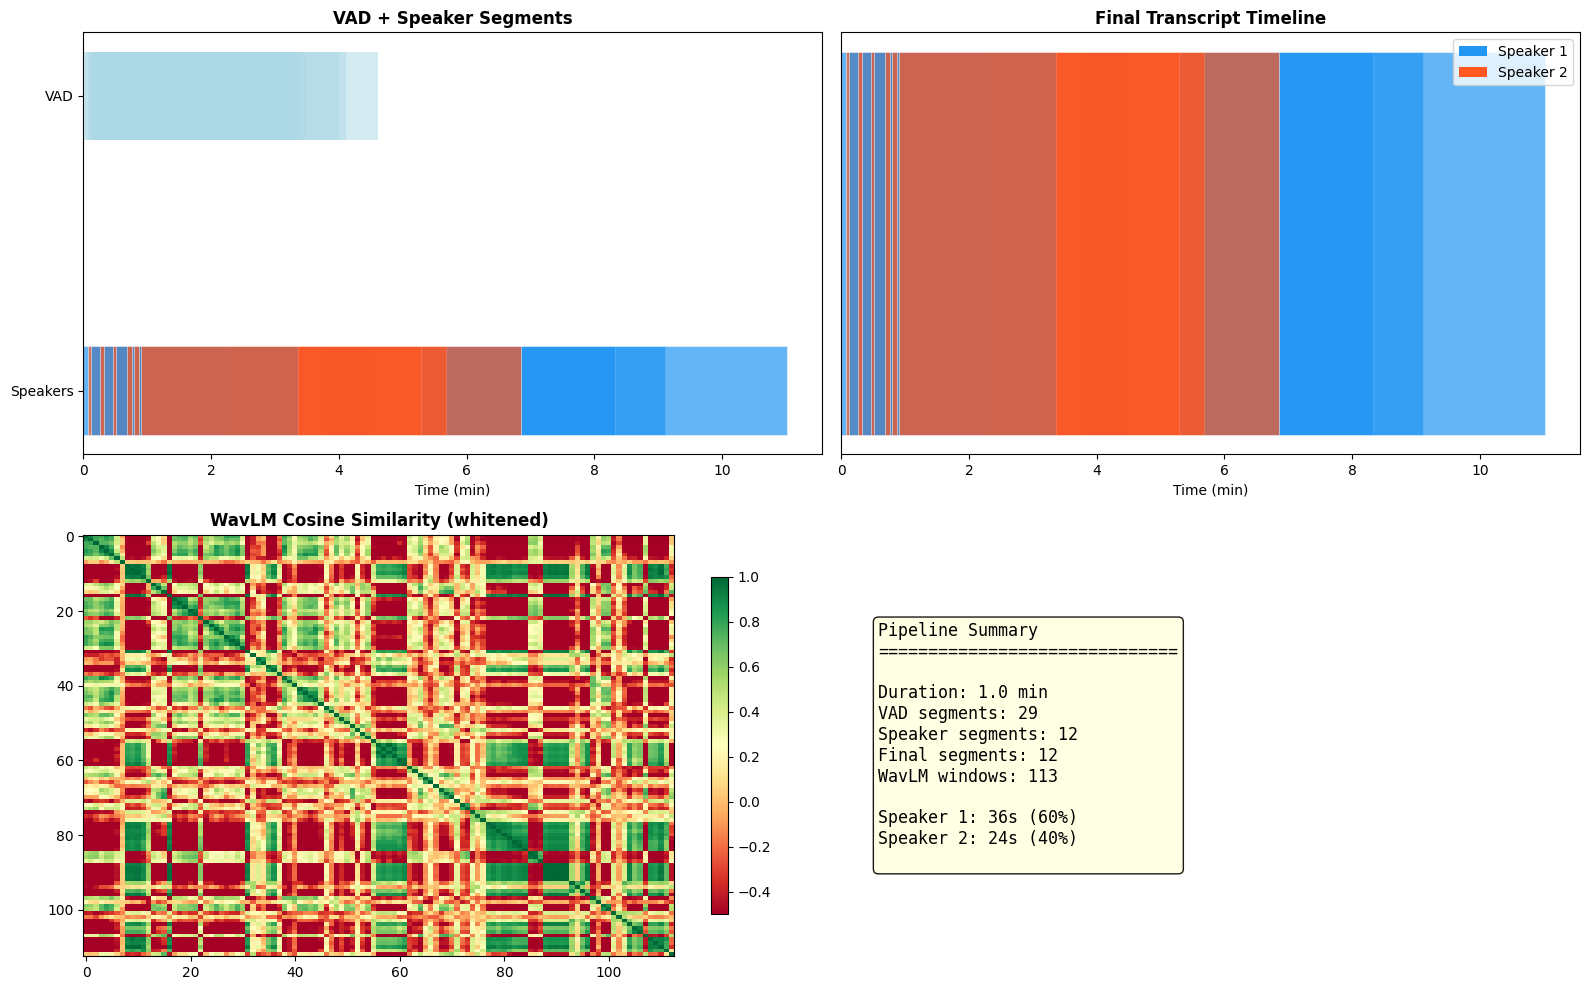

In [30]:
# Cell 12: Visualization
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

# 1. VAD + Speaker Segments
ax = axes[0, 0]
for s, e in vad_segments:
    ax.barh(1, e-s, left=s/60, height=0.3, color='lightblue', alpha=0.5)
for seg in speaker_segments:
    spk = seg.get('final_speaker', seg.get('wavlm_speaker')) - 1
    ax.barh(0, seg['end']-seg['start'], left=seg['start']/60, height=0.3,
            color=colors[spk%4], alpha=0.7, edgecolor='white', linewidth=0.5)
ax.set_yticks([0, 1]); ax.set_yticklabels(['Speakers', 'VAD'])
ax.set_title('VAD + Speaker Segments', fontweight='bold')
ax.set_xlabel('Time (min)')

# 2. Final Timeline
ax = axes[0, 1]
for p in predictions:
    spk = int(p['speaker'].split()[-1]) - 1
    ax.barh(0, p['end']-p['start'], left=p['start']/60, height=0.5,
            color=colors[spk%4], alpha=0.7, edgecolor='white', linewidth=0.5)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=colors[i], label=f'Speaker {i+1}') for i in range(cfg.NUM_SPEAKERS_EXPECTED)]
ax.legend(handles=legend_els, loc='upper right')
ax.set_title('Final Transcript Timeline', fontweight='bold')
ax.set_xlabel('Time (min)'); ax.set_yticks([])

# 3. Cosine Similarity
ax = axes[1, 0]
sim = cosine_similarity(embs_final)
im = ax.imshow(sim, cmap='RdYlGn', vmin=-0.5, vmax=1.0, aspect='auto')
ax.set_title('WavLM Cosine Similarity (whitened)', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# 4. Summary
ax = axes[1, 1]; ax.axis('off')
txt = f"Pipeline Summary\n{'='*30}\n\n"
txt += f"Duration: {duration/60:.1f} min\n"
txt += f"VAD segments: {len(vad_segments)}\n"
txt += f"Speaker segments: {len(speaker_segments)}\n"
txt += f"Final segments: {len(predictions)}\n"
txt += f"WavLM windows: {len(windows_audio)}\n\n"
for spk, dur in sorted(spk_durs.items()):
    txt += f"{spk}: {dur:.0f}s ({dur/duration*100:.0f}%)\n"
ax.text(0.05, 0.5, txt, transform=ax.transAxes, fontsize=12,
        va='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/pipeline_results.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Export


In [31]:
# Cell 13: Export TXT / SRT / JSON
name = 'pipeline_output'

# TXT
txt_path = f'{cfg.OUTPUT_DIR}/{name}.txt'
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(f"# Output")
    f.write(f"# {duration/60:.1f} min | {len(predictions)} segments\n\n")
    for p in predictions:
        h, m, s = int(p['start']//3600), int((p['start']%3600)//60), int(p['start']%60)
        f.write(f"[{h:02d}:{m:02d}:{s:02d}] {p['speaker']}: {p['text']}\n")

# SRT
srt_path = f'{cfg.OUTPUT_DIR}/{name}.srt'
with open(srt_path, 'w', encoding='utf-8') as f:
    for i, p in enumerate(predictions, 1):
        sh,sm,ss = int(p['start']//3600), int((p['start']%3600)//60), p['start']%60
        eh,em,es = int(p['end']//3600), int((p['end']%3600)//60), p['end']%60
        f.write(f"{i}\n{sh:02d}:{sm:02d}:{ss:06.3f} --> {eh:02d}:{em:02d}:{es:06.3f}\n")
        f.write(f"{p['speaker']}: {p['text']}\n\n")

# JSON
json_path = f'{cfg.OUTPUT_DIR}/{name}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump({
        'pipeline': 'Upload -> VAD -> Cut&Merge -> WavLM Diarization -> ASR -> Merge',
        'duration': duration,
        'stats': {
            'vad_segments': len(vad_segments),
            'speaker_segments': len(speaker_segments),
            'final_segments': len(predictions),
            'wavlm_windows': len(windows_audio)
        },
        'segments': [{
            'start': p['start'], 'end': p['end'],
            'speaker': p['speaker'], 'text': p['text']
        } for p in predictions]
    }, f, ensure_ascii=False, indent=2)

print(f"\u2713 TXT: {txt_path}")
print(f"\u2713 SRT: {srt_path}")
print(f"\u2713 JSON: {json_path}")

# Download files
from google.colab import files as dl_files
for path in [txt_path, srt_path, json_path]:
    dl_files.download(path)


✓ TXT: /content/drive/MyDrive/Method/results_pipeline/pipeline_output.txt
✓ SRT: /content/drive/MyDrive/Method/results_pipeline/pipeline_output.srt
✓ JSON: /content/drive/MyDrive/Method/results_pipeline/pipeline_output.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>